# Google Maps Traffic — PNG Tile Approach

This notebook fetches **real-time traffic congestion** from **Google Maps traffic PNG tiles**
and assigns the congestion level directly to every edge in the duckOSM road network.

## How it differs from the Mapbox approach (notebook 3)

| Aspect | Mapbox (notebook 3) | Google PNG (this notebook) |
|---|---|---|
| Tile format | MVT binary (vector) | PNG raster image |
| Congestion encoding | property on each road segment | pixel **color** in the image |
| Contains geometry | Yes — LineString segments | No — only pixels |
| Extra step needed | Spatial map matching (notebook 4) | **None** — pixels sampled directly on OSM edges |

Because Google PNG tiles encode congestion as **color**, and we already have the OSM
edge geometry in DuckDB, we sample pixel colors **along each edge** and map them to
a congestion level — skipping the separate map-matching step entirely.

## Google Maps Traffic tile URL

```
https://maps.googleapis.com/maps/vt?lyrs=traffic&x={x}&y={y}&z={z}&key={API_KEY}
```

This returns a **256 × 256 RGBA PNG** with only the traffic overlay (no base map).
Transparent pixels mean no traffic data for that location.

## Color → congestion mapping

Google encodes congestion as road line colors in the PNG. We use the **HSV color space**
(Hue, Saturation, Value) which separates color (H) from brightness (V), making it more
robust than raw RGB comparisons:

| Pixel color | HSV range | Congestion |
|---|---|---|
| 🟢 Green | H 90–150°, S>40%, V>40% | `low` |
| 🟠 Orange/Yellow | H 20–60°, S>50%, V>60% | `moderate` |
| 🔴 Red | H 0–20° or 340–360°, S>60%, V>50% | `heavy` |
| ⬛ Dark red | H 0–20° or 340–360°, S>40%, V≤50% | `severe` |
| Transparent / gray | alpha<30 or S<15% or V<15% | no data |

## Pipeline

```
DuckDB (driving.edges)
        │
        ▼
Step 1 — Load OSM edge geometries
        │
        ▼
Step 2 — Find all tiles covering the boundary
        │
        ▼
Step 3 — Download Google traffic PNG tiles  (cached in tiles/google/)
        │
        ▼
Step 4 — Define color helpers
        │
        ▼
Step 5 — Sample pixel colors along each OSM edge → majority vote → congestion
        │
        ▼
Step 6 — Write congestion to DuckDB  (driving.edges + edge_congestion_history)
        │
        ▼
Step 7 — Visualize  →  Step 8 — Export CSV / GeoJSON
```

In [ ]:
%pip install Pillow --quiet   # PIL for reading PNG tiles

---
## Configuration

- `GOOGLE_MAPS_API_KEY` — get a Maps API key at [console.cloud.google.com](https://console.cloud.google.com/).
  Enable the **Maps Tile API** or **Maps JavaScript API** for your project.
  Add the key to your `.env` file as `GOOGLE_MAPS_API_KEY=AIza...`
- `ZOOM` — tile zoom level. Higher zoom = smaller tiles = more pixel detail per road,
  but more tiles to download. **14** is recommended (same as Mapbox).
- `N_SAMPLES` — number of points to sample along each OSM edge.
  More samples = more accurate but slower. **8** is a good default.

In [1]:
%%time
import os, colorsys, time, yaml
import numpy as np
import duckdb
import geopandas as gpd
import mercantile
import requests
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from shapely.geometry import box
from shapely import get_coordinates
from shapely.geometry import LineString
from dotenv import load_dotenv

load_dotenv(Path('../.env'), override=True)

# ── Configuration ─────────────────────────────────────────────────────────
NAME               = 'sodermalm'
ZOOM               = 14       # tile zoom level (14 recommended)
N_SAMPLES          = 8        # pixel sample points per OSM edge
GOOGLE_API_KEY     = os.environ.get('GOOGLE_MAPS_API_KEY', '')
TILES_DIR          = Path('../tiles/google')   # PNG tile cache
OUTPUT_DIR         = Path('../output')
# ─────────────────────────────────────────────────────────────────────────

# Read DuckDB path from config YAML
CONFIG_PATH = Path(f'../config/{NAME}.yaml')
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    DB_PATH       = Path(cfg['output_path']) / f"{cfg['name']}.duckdb"
    BOUNDARY_FILE = Path(cfg['boundary_path'])
else:
    DB_PATH       = Path(f'../db/{NAME}.duckdb')
    BOUNDARY_FILE = Path(f'../boundaries/{NAME}.geojson')
    print('WARNING: config not found — using default paths')

TILES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

if not GOOGLE_API_KEY:
    print('WARNING: GOOGLE_MAPS_API_KEY not set — add it to ../.env')
else:
    print(f'API key  : {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]}')
print(f'DuckDB   : {DB_PATH}')
print(f'Boundary : {BOUNDARY_FILE}')
print(f'Zoom     : {ZOOM}   N_SAMPLES: {N_SAMPLES}')

DuckDB   : /home/kaveh/projects/osm-traffic-enrichment/map/sodermalm.duckdb
Boundary : /home/kaveh/projects/osm-traffic-enrichment/boundaries/sodermalm.geojson
Zoom     : 14   N_SAMPLES: 8
CPU times: user 2.14 s, sys: 217 ms, total: 2.36 s
Wall time: 1.08 s


---
## Step 1 — Load OSM edges from DuckDB

We read the `driving.edges` table that was built by notebook 2 (duckOSM).
The geometry column is stored as a DuckDB `GEOMETRY` type — we export it as WKT
and parse into shapely so we can compute sample points along each edge.

We keep only **line geometries** (LineString / MultiLineString) since the pixel
sampling requires a path to interpolate along.

In [2]:
%%time
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute('LOAD spatial')

df = con.execute("""
    SELECT edge_id, highway, name, length_m,
           ST_AsText(geometry) AS wkt_geom
    FROM driving.edges
""").df()
con.close()

edges = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['wkt_geom']),
    crs='EPSG:4326',
).reset_index(drop=True)

# Keep only line geometries — point features can't be sampled along
edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]

print(f'Loaded {len(edges):,} line edges from {DB_PATH.name}')
print(f'Total network length: {edges["length_m"].sum()/1000:.1f} km')
print(f'Highway types: {sorted(edges["highway"].unique())}')

Loaded 4,554 line edges from sodermalm.duckdb
Total network length: 191.6 km
Highway types: ['living_street', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'service', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'unclassified']
CPU times: user 467 ms, sys: 157 ms, total: 623 ms
Wall time: 102 ms


---
## Step 2 — Find tiles covering the boundary

We use `mercantile` to enumerate all tiles at the chosen zoom level whose footprint
overlaps the boundary polygon. This is the same tile grid used for the Mapbox approach.

One PNG tile covers approximately **1 km × 1 km** at zoom 14 in Sweden.
Each tile is 256 × 256 pixels, so each pixel represents about **4 m × 4 m**.

In [3]:
%%time
gdf      = gpd.read_file(BOUNDARY_FILE).to_crs('EPSG:4326')
boundary = gdf.geometry.union_all()
w, s, e, n = boundary.bounds

tiles = [
    t for t in mercantile.tiles(w, s, e, n, zooms=ZOOM)
    if boundary.intersects(box(*mercantile.bounds(t)))
]

print(f'Boundary  : W={w:.4f} S={s:.4f} E={e:.4f} N={n:.4f}')
print(f'Tiles     : {len(tiles)} at zoom {ZOOM}')
print(f'Pixel res : ~{mercantile.bounds(tiles[0]).east - mercantile.bounds(tiles[0]).west:.4f}° per tile')

Boundary  : W=18.0261 S=59.3032 E=18.1072 N=59.3214
Tiles     : 8 at zoom 14
Pixel res : ~0.0220° per tile
CPU times: user 5.98 ms, sys: 25.2 ms, total: 31.2 ms
Wall time: 80.5 ms


---
## Step 3 — Download Google Maps traffic PNG tiles

### Tile URL format
```
https://maps.googleapis.com/maps/vt?lyrs=traffic&x={x}&y={y}&z={z}&key={API_KEY}
```
- `lyrs=traffic` requests the **traffic-only overlay** (no base map), returning a
  transparent PNG where only traffic-colored pixels are non-transparent.
- Tiles are downloaded in parallel (6 workers) and cached in `tiles/google/`.
  Re-running this cell with cached tiles is instant.

### What the tile contains
The PNG is RGBA (Red, Green, Blue, Alpha). Pixels with `alpha < 30` are fully
transparent — these locations have no traffic data. Traffic-colored pixels have
high alpha and one of the four congestion colors.

In [4]:
%%time
GOOGLE_TILE_URL = 'https://maps.googleapis.com/maps/vt'

def download_google_tile(tile, api_key, out_dir, retries=3):
    """Download one Google Maps traffic PNG tile. Returns (tile, Path) or (tile, None).
    Files are cached — already-downloaded tiles are returned immediately.
    """
    path = out_dir / f'{tile.z}_{tile.x}_{tile.y}.png'
    if path.exists():
        return tile, path

    params = {'lyrs': 'traffic', 'x': tile.x, 'y': tile.y, 'z': tile.z, 'key': api_key}
    for attempt in range(retries):
        try:
            r = requests.get(GOOGLE_TILE_URL, params=params, timeout=(5, 20))
        except requests.exceptions.Timeout:
            time.sleep(2 ** attempt)
            continue
        if r.status_code == 200:
            path.write_bytes(r.content)
            return tile, path
        if r.status_code == 429:
            time.sleep(2 ** attempt)   # rate-limited — back off
        else:
            print(f'  {tile} HTTP {r.status_code}: {r.text[:80]}')
            return tile, None
    return tile, None


# Download all tiles in parallel
tile_paths = {}
failed     = []
with ThreadPoolExecutor(max_workers=6) as pool:
    futures = {pool.submit(download_google_tile, t, GOOGLE_API_KEY, TILES_DIR): t
               for t in tiles}
    for f in as_completed(futures):
        tile, path = f.result()
        if path:
            tile_paths[tile] = path
        else:
            failed.append(tile)

print(f'Downloaded : {len(tile_paths)}/{len(tiles)} tiles')
if failed:
    print(f'Failed     : {len(failed)} tiles — check API key and quota')

Downloaded : 8/8 tiles
CPU times: user 35.4 ms, sys: 27.1 ms, total: 62.5 ms
Wall time: 752 ms


### Inspect a sample tile

Before running the full analysis, it is worth visualising one tile to verify that
the downloaded PNG actually contains traffic colors. A correct tile shows:
- Transparent background (checkerboard pattern when displayed)
- Colored lines along roads: green, orange, or red

Tile     : Tile(x=9012, y=4819, z=14)
Size     : (1, 1)  (width x height pixels)
Visible  : 0 / 1 pixels (0.0%) have traffic data


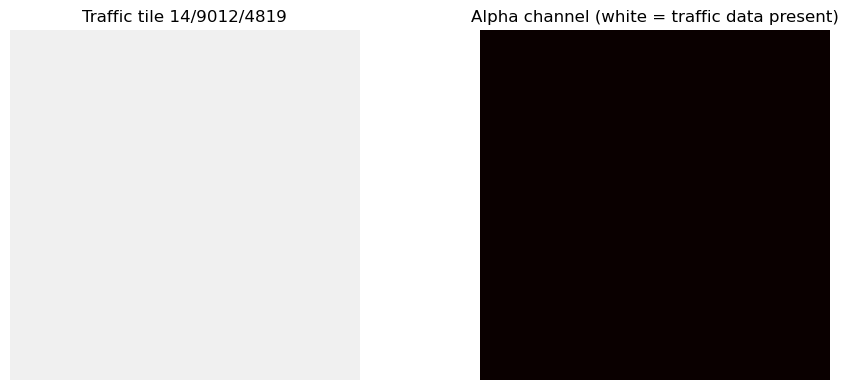

CPU times: user 69 ms, sys: 19.5 ms, total: 88.5 ms
Wall time: 99 ms


In [5]:
%%time
if tile_paths:
    sample_tile, sample_path = next(iter(tile_paths.items()))
    img = Image.open(sample_path).convert('RGBA')
    arr = np.array(img)

    # Count non-transparent pixels (alpha > 30) to confirm traffic data present
    visible = (arr[:, :, 3] > 30).sum()
    total   = arr.shape[0] * arr.shape[1]
    print(f'Tile     : {sample_tile}')
    print(f'Size     : {img.size}  (width x height pixels)')
    print(f'Visible  : {visible:,} / {total:,} pixels ({visible/total*100:.1f}%) have traffic data')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Show the tile (transparent = white background for display)
    bg = Image.new('RGB', img.size, (240, 240, 240))
    bg.paste(img, mask=img.split()[3])
    axes[0].imshow(bg)
    axes[0].set_title(f'Traffic tile {sample_tile.z}/{sample_tile.x}/{sample_tile.y}')
    axes[0].axis('off')
    # Show only the alpha channel to visualise coverage
    axes[1].imshow(arr[:, :, 3], cmap='hot')
    axes[1].set_title('Alpha channel (white = traffic data present)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

---
## Step 4 — Color classification helpers

### Why HSV instead of RGB?

RGB mixes color and brightness together, making thresholds brittle (e.g. a dark red
and a bright red look very different in RGB but both have Hue ≈ 0° in HSV).

**HSV** separates three independent axes:
- **H** (Hue 0–360°): the color itself — red=0°, yellow=60°, green=120°
- **S** (Saturation 0–1): how vivid — 0 = gray, 1 = pure color
- **V** (Value 0–1): brightness — 0 = black, 1 = bright

### `pixel_to_congestion(r, g, b, a)`
Classifies a single RGBA pixel into a congestion level.
Returns `None` for transparent or gray pixels (no traffic data).

### `sample_edge_congestion(geom, tile_imgs, zoom)`
Interpolates `N_SAMPLES` evenly-spaced points along an edge LineString,
samples the pixel color at each point, and returns the majority congestion
level. Severity is used as a tiebreaker (heavy beats moderate if tied).

In [6]:
%%time

def pixel_to_congestion(r, g, b, a):
    """Map a single RGBA pixel to a congestion level string, or None.

    Classification is done in HSV space:
      H (hue)        — which color family (green / orange / red)
      S (saturation) — how vivid (rejects gray background pixels)
      V (value)      — brightness (distinguishes red from dark red)
    """
    if a < 30:                      # nearly transparent → no traffic data
        return None

    h, s, v = colorsys.rgb_to_hsv(r/255, g/255, b/255)
    h_deg   = h * 360              # convert 0–1 to 0–360 degrees

    if s < 0.15 or v < 0.15:       # too gray or too dark → not a traffic color
        return None

    # Green → free flow
    if 90 <= h_deg <= 150 and s > 0.40 and v > 0.40:
        return 'low'

    # Yellow / Orange → slow
    if 20 <= h_deg < 90 and s > 0.50 and v > 0.60:
        return 'moderate'

    # Red (hue wraps around 360°) → heavy
    if (h_deg < 20 or h_deg > 340) and s > 0.60 and v > 0.50:
        return 'heavy'

    # Dark red → severe
    if (h_deg < 20 or h_deg > 340) and s > 0.40 and v <= 0.50:
        return 'severe'

    return None   # unrecognised color


def sample_edge_congestion(geom, tile_imgs, zoom, n_samples=N_SAMPLES):
    """Sample pixel colors along an OSM edge and return the majority congestion.

    Steps:
      1. Interpolate n_samples evenly-spaced points along the edge geometry
      2. For each point: find its tile, convert lon/lat → pixel (col, row)
      3. Look up the pixel color in the cached RGBA PIL Image
      4. Classify each pixel with pixel_to_congestion()
      5. Return the most common congestion level (severity breaks ties)
    """
    SEVERITY = {'severe': 4, 'heavy': 3, 'moderate': 2, 'low': 1}
    results  = []

    # Use the first ring of coords for MultiLineString
    coords = get_coordinates(geom)
    if len(coords) < 2:
        return 'no data'

    line = LineString(coords)
    distances = np.linspace(0, 1, n_samples)

    for d in distances:
        pt  = line.interpolate(d, normalized=True)
        lon, lat = pt.x, pt.y

        # Find which tile this point belongs to
        tile = mercantile.tile(lon, lat, zoom)
        key  = (tile.x, tile.y, tile.z)
        if key not in tile_imgs:
            continue

        img    = tile_imgs[key]
        bounds = mercantile.bounds(tile)

        # Convert geographic coordinates to pixel position (0–255)
        col = int((lon - bounds.west)  / (bounds.east  - bounds.west)  * 255)
        row = int((bounds.north - lat) / (bounds.north - bounds.south) * 255)
        col = max(0, min(255, col))   # clamp to valid range
        row = max(0, min(255, row))

        r, g, b, a = img.getpixel((col, row))
        cong = pixel_to_congestion(r, g, b, a)
        if cong:
            results.append(cong)

    if not results:
        return 'no data'

    # Majority vote with severity as tiebreaker
    return max(set(results), key=lambda c: (results.count(c), SEVERITY.get(c, 0)))


print('Helper functions defined: pixel_to_congestion(), sample_edge_congestion()')

# Quick sanity check on the color classifier
test_cases = [
    ((80,  200, 60,  255), 'expected: low      '),
    ((255, 160, 30,  255), 'expected: moderate '),
    ((220, 40,  20,  255), 'expected: heavy    '),
    ((120, 20,  20,  255), 'expected: severe   '),
    ((200, 200, 200, 255), 'expected: None     '),
    ((80,  200, 60,  10 ), 'expected: None (transparent)'),
]
print('\nColor classifier sanity check:')
for (r, g, b, a), label in test_cases:
    result = pixel_to_congestion(r, g, b, a)
    print(f'  RGB({r:3},{g:3},{b:3}) alpha={a:3}  →  {str(result):<10}  {label}')

Helper functions defined: pixel_to_congestion(), sample_edge_congestion()

Color classifier sanity check:
  RGB( 80,200, 60) alpha=255  →  low         expected: low      
  RGB(255,160, 30) alpha=255  →  moderate    expected: moderate 
  RGB(220, 40, 20) alpha=255  →  heavy       expected: heavy    
  RGB(120, 20, 20) alpha=255  →  severe      expected: severe   
  RGB(200,200,200) alpha=255  →  None        expected: None     
  RGB( 80,200, 60) alpha= 10  →  None        expected: None (transparent)
CPU times: user 93 μs, sys: 0 ns, total: 93 μs
Wall time: 89.2 μs


---
## Step 5 — Sample pixel colors along every OSM edge

This is the core step that replaces the geometric map-matching used in the Mapbox
approach. Instead of matching Mapbox segment geometries to OSM edges, we use the
OSM edge geometry itself as a sampling path through the traffic tile pixels.

**Why this works:** Both the OSM edges and the Google traffic tiles are referenced
in the same coordinate system (WGS-84 / Web Mercator tile grid), so converting
an OSM edge coordinate to a pixel position in the tile is straightforward.

**Performance note:** Loading all PNG tiles into memory first (as RGBA PIL Images)
means each `getpixel()` call is O(1) — no disk I/O during the sampling loop.

In [7]:
%%time
# Load all downloaded PNG tiles into memory as RGBA PIL Images
# Key: (x, y, z) → PIL Image  so lookup is O(1) per pixel
tile_imgs = {}
for tile, path in tile_paths.items():
    try:
        tile_imgs[(tile.x, tile.y, tile.z)] = Image.open(path).convert('RGBA')
    except Exception as e:
        print(f'  Could not load {path.name}: {e}')

print(f'Loaded {len(tile_imgs)} PNG tiles into memory')

# Sample each OSM edge
edge_congestion = {}   # edge_id (int) → congestion string
no_data_count   = 0

for _, row in edges.iterrows():
    cong = sample_edge_congestion(row.geometry, tile_imgs, ZOOM)
    if cong != 'no data':
        edge_congestion[int(row['edge_id'])] = cong
    else:
        no_data_count += 1

# Apply to the edges GeoDataFrame for visualisation and export
edges['congestion'] = edges['edge_id'].map(edge_congestion).fillna('no data')

matched_pct = len(edge_congestion) / max(len(edges), 1) * 100
print(f'\nEdges with congestion : {len(edge_congestion):,} / {len(edges):,}  ({matched_pct:.1f}%)')
print(f'Edges with no data    : {no_data_count:,}')
print('\nCongestion distribution:')
print(edges['congestion'].value_counts().to_string())

Loaded 8 PNG tiles into memory


IndexError: image index out of range

---
## Step 6 — Write congestion to DuckDB

Two writes happen here:

1. **Latest snapshot** — `driving.edges.congestion` is updated with the current values.
   This is what routing tools and queries will read.

2. **History** — one row per edge is appended to `edge_congestion_history` with the
   current `run_id` and timestamp. This keeps a time-series record that can be queried
   to see how congestion changed between Google fetches over time.

The `runs` table also gets a new row recording the metadata of this fetch
(source: `google`, timestamp, tile count, edge count).

In [ ]:
%%time
import pandas as pd
from datetime import datetime, timezone

fetched_at = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

con = duckdb.connect(str(DB_PATH))
con.execute('LOAD spatial')

# ── runs table — log this fetch execution ─────────────────────────────────
con.execute("""
    CREATE TABLE IF NOT EXISTS runs (
        run_id        INTEGER PRIMARY KEY,
        boundary_name VARCHAR,
        zoom          INTEGER,
        fetched_at    TIMESTAMP,
        n_tiles       INTEGER,
        n_segments    INTEGER
    )
""")
run_id = con.execute("SELECT coalesce(max(run_id), 0) + 1 FROM runs").fetchone()[0]
con.execute("INSERT INTO runs VALUES (?, ?, ?, ?, ?, ?)",
            [run_id, f'{NAME}_google', ZOOM, fetched_at,
             len(tile_paths), len(edge_congestion)])

# ── driving.edges.congestion — update latest snapshot ─────────────────────
con.execute("ALTER TABLE driving.edges ADD COLUMN IF NOT EXISTS congestion VARCHAR DEFAULT 'no data'")
con.executemany("UPDATE driving.edges SET congestion = ? WHERE edge_id = ?",
                [(cong, eid) for eid, cong in edge_congestion.items()])

# ── edge_congestion_history — append time-series record ───────────────────
con.execute("""
    CREATE TABLE IF NOT EXISTS edge_congestion_history (
        run_id     INTEGER,
        edge_id    INTEGER,
        congestion VARCHAR,
        matched_at TIMESTAMP
    )
""")
con.executemany("INSERT INTO edge_congestion_history VALUES (?, ?, ?, ?)",
                [(run_id, int(eid), cong, fetched_at)
                 for eid, cong in edge_congestion.items()])

total_history = con.execute("SELECT count(*) FROM edge_congestion_history").fetchone()[0]
total_runs    = con.execute("SELECT count(*) FROM runs").fetchone()[0]
con.close()

print(f'Run ID           : {run_id}  (source: Google Maps PNG)')
print(f'Edges updated    : {len(edge_congestion):,}')
print(f'History total    : {total_history:,} rows across {total_runs} run(s)')
print(f'Fetched at       : {fetched_at} UTC')

---
## Step 7 — Visualize

The folium map shows every OSM edge colored by the congestion level sampled from
Google Maps. Open Google Maps in another tab and enable the traffic layer on the
same area to compare visually.

| Color | Congestion | Meaning |
|---|---|---|
| 🟢 Green | `low` | Free flow — sampled green pixels |
| 🟠 Orange | `moderate` | Reduced speed — sampled orange/yellow pixels |
| 🔴 Red | `heavy` | Significant slowdown — sampled red pixels |
| ⬛ Dark red | `severe` | Near standstill — sampled dark red pixels |
| ⬜ Gray | `no data` | Tile not available or no traffic pixels on this edge |

In [ ]:
%%time
COLORS = {'low':'#00c800','moderate':'#ffa500','heavy':'#ff4500','severe':'#8b0000','no data':'#cccccc'}

lines  = edges[edges.geometry.geom_type.isin(['LineString','MultiLineString'])]
bds    = lines.total_bounds
center = [(bds[1]+bds[3])/2, (bds[0]+bds[2])/2]

m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')
folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda _: {'color':'navy','weight':2,'fillOpacity':0.05},
    tooltip=None, popup=None,
).add_to(m)
folium.GeoJson(
    lines.__geo_interface__,
    style_function=lambda feat: {
        'color':  COLORS.get(feat['properties'].get('congestion','no data'),'#cccccc'),
        'weight': 3 if feat['properties'].get('congestion','no data') != 'no data' else 1.5,
    },
    tooltip=None, popup=None,
).add_to(m)
m

---
## Step 8 — Export CSV and GeoJSON

Save the enriched edges as files alongside the Mapbox outputs so they can be
compared or used in QGIS / kepler.gl.

The `_google` suffix in the filename distinguishes these from Mapbox outputs.

In [ ]:
%%time
from shapely import get_coordinates as gc

geojson_out = OUTPUT_DIR / f'{NAME}_edges_traffic_google.geojson'
csv_out     = OUTPUT_DIR / f'{NAME}_edges_traffic_google.csv'

edges.to_file(geojson_out, driver='GeoJSON')
print(f'Saved GeoJSON → {geojson_out}  ({len(edges):,} edges)')

csv_df = edges.drop(columns=['geometry','wkt_geom'], errors='ignore').copy()
edges_m = edges.to_crs('EPSG:3857')
centroids        = edges_m.geometry.centroid.to_crs('EPSG:4326')
csv_df['lon']    = centroids.x.round(6)
csv_df['lat']    = centroids.y.round(6)
csv_df['length_m'] = edges_m.geometry.length.round(1)
all_coords           = edges.geometry.apply(gc)
csv_df['start_lon']  = all_coords.apply(lambda c: round(c[ 0][0], 6))
csv_df['start_lat']  = all_coords.apply(lambda c: round(c[ 0][1], 6))
csv_df['end_lon']    = all_coords.apply(lambda c: round(c[-1][0], 6))
csv_df['end_lat']    = all_coords.apply(lambda c: round(c[-1][1], 6))
csv_df.to_csv(csv_out, index=False)
print(f'Saved CSV     → {csv_out}')

print(f'\nFinal congestion distribution:')
print(edges['congestion'].value_counts().to_string())